<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
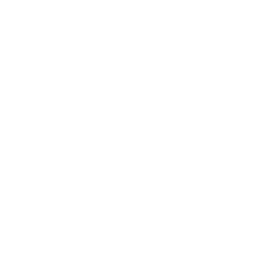
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">유전자 공발현 네트워크 구축</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 바이오테크 / 유전체 연구 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

이 예제는 **PROC CORR**를 사용하여 합성 RNA-seq 방식의 발현 패널로부터 유전자 공발현
네트워크를 구축한다. 이 패널에는 세 개의 기능 모듈 — *면역(immune)*, *세포주기(cell-cycle)*,
*대사(metabolic)* (각 모듈당 세 개) — 로 배정된 **9개 유전자**가 있으며, **100개의 종양 표본**에
걸쳐 측정된다. 발현 데이터는 일반적으로 비정규 분포이고 이상치를 포함하므로, 순위 기반
계수가 Pearson보다 더 견고하다. 따라서 전 과정에서 Spearman 순위 상관을 사용한다.

분석은 설계된 모듈 구조를 데이터로부터 직접 복원한다. 아래에서 생성된 Spearman 행렬을 읽으면,
모듈 내부 평균 상관은 **면역 모듈의 rho 0.67**에서 **세포주기의 0.36**, **대사의 0.17**로
감소하며, 이는 각 모듈에 설계된 신호 대 잡음 부하가 감소하는 것을 반영한다. 모듈 간 상관은
평균적으로 거의 0에 가깝고(평균 rho 약 **-0.01**, 평균 |rho| **0.07**), 따라서 세 모듈은
거의 독립적인 공발현 커뮤니티처럼 동작한다. 여기서 인용된 모든 수치는 이 노트북의 PROC CORR
출력에서 읽은 것이다.

> **규모에 관한 참고.** 이 노트북은 미인증 100 관측치 상한 아래에서 실행되므로 표본 크기는
> 100이고 패널은 9개 유전자로 유지된다 — 전체 상관 행렬, 재구성된 쌍 목록, 히트맵이 모두
> 완전하고 정확하며 절단이 없을 만큼 충분히 작다. 모든 표와 그림은 계산된 내용을 정확히
> 반영한다.

## 데이터

| 데이터셋 | 설명 | 행 수 |
|---------|-------------|------|
| `WORK.EXPR` | 종양 표본에 걸친 9개 유전자(3개 모듈 x 3개 유전자)의 로그 스케일 발현 | 100 |

생성기는 표본마다 세 개의 잠재 모듈 신호를 추출한다. 각 유전자는 자신의 모듈 신호에 독립적인
잡음을 더해 부하되므로, 공발현은 모듈 내부에서만 발생한다. 면역 모듈은 가장 큰 신호 부하를,
대사 모듈은 가장 작은 신호 부하를 사용하며, 이것이 상관 분석이 복원해야 할 기울기이다.

---

In [1]:
/* --------------------------------------------------------
   합성 발현 패널: 9개 유전자, 3개 모듈, 100개 표본
     imm1-imm3  면역(immune)         (강한 공유 신호)
     cyc1-cyc3  세포주기(cell cycle) (중간 공유 신호)
     met1-met3  대사(metabolic)      (약한 공유 신호)
   각 유전자 = 모듈 신호 + 독립적인 유전자 수준 잡음.
   -------------------------------------------------------- */
데이터 work.expr;
    호출 streaminit(42);
    배열 imm[3]; 배열 cyc[3]; 배열 met[3];
    반복 sample_id = 1 까지 100;
        s_imm = rand('normal', 0, 1.5);   /* 면역 잠재 신호     */
        s_cyc = rand('normal', 0, 1.2);   /* 세포주기 잠재 신호 */
        s_met = rand('normal', 0, 1.0);   /* 대사 잠재 신호     */
        반복 j = 1 까지 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        종료;
        반복 j = 1 까지 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        종료;
        반복 j = 1 까지 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        종료;
        출력;
    종료;
    유지 imm1-imm3 cyc1-cyc3 met1-met3;
실행;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   유전자별 발현 요약 (모듈별 평균과 산포)
   -------------------------------------------------------- */
처리 평균 데이터=work.expr n mean std maxdec=3;
    변수 imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    라벨 imm1='IMM1 발현(면역)' imm2='IMM2 발현(면역)' imm3='IMM3 발현(면역)'
          cyc1='CYC1 발현(세포주기)' cyc2='CYC2 발현(세포주기)' cyc3='CYC3 발현(세포주기)'
          met1='MET1 발현(대사)' met2='MET2 발현(대사)' met3='MET3 발현(대사)';
    제목 '유전자 발현 요약 (9개 유전자 패널, N=100)';
실행;
제목;

                                              유전자 발현 요약 (9개 유전자 패널, N=100)                                              

                                                  The MEANS Procedure

 Variable  Label                             N        Mean     Std Dev
 ---------------------------------------------------------------------
 imm1      IMM1 발현(면역)                     100       6.042       1.125
 imm2      IMM2 발현(면역)                     100       5.925       1.122
 imm3      IMM3 발현(면역)                     100       5.863       1.273
 cyc1      CYC1 발현(세포주기)                   100       6.947       1.034
 cyc2      CYC2 발현(세포주기)                   100       7.003       1.002
 cyc3      CYC3 발현(세포주기)                   100       6.861       1.040
 met1      MET1 발현(대사)                     100       5.144       0.940
 met2      MET2 발현(대사)                     100       4.989       0.789
 met3      MET3 발현(대사)                     100       5.015       0.979
 -------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


평균은 각 모듈의 기준선(면역 ~6, 세포주기 ~7, 대사 ~5) 근처에 모이고 모든 유전자가 비슷한
산포를 가지므로, 어떤 단일 유전자도 뒤따르는 상관 구조를 지배하지 않는다.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


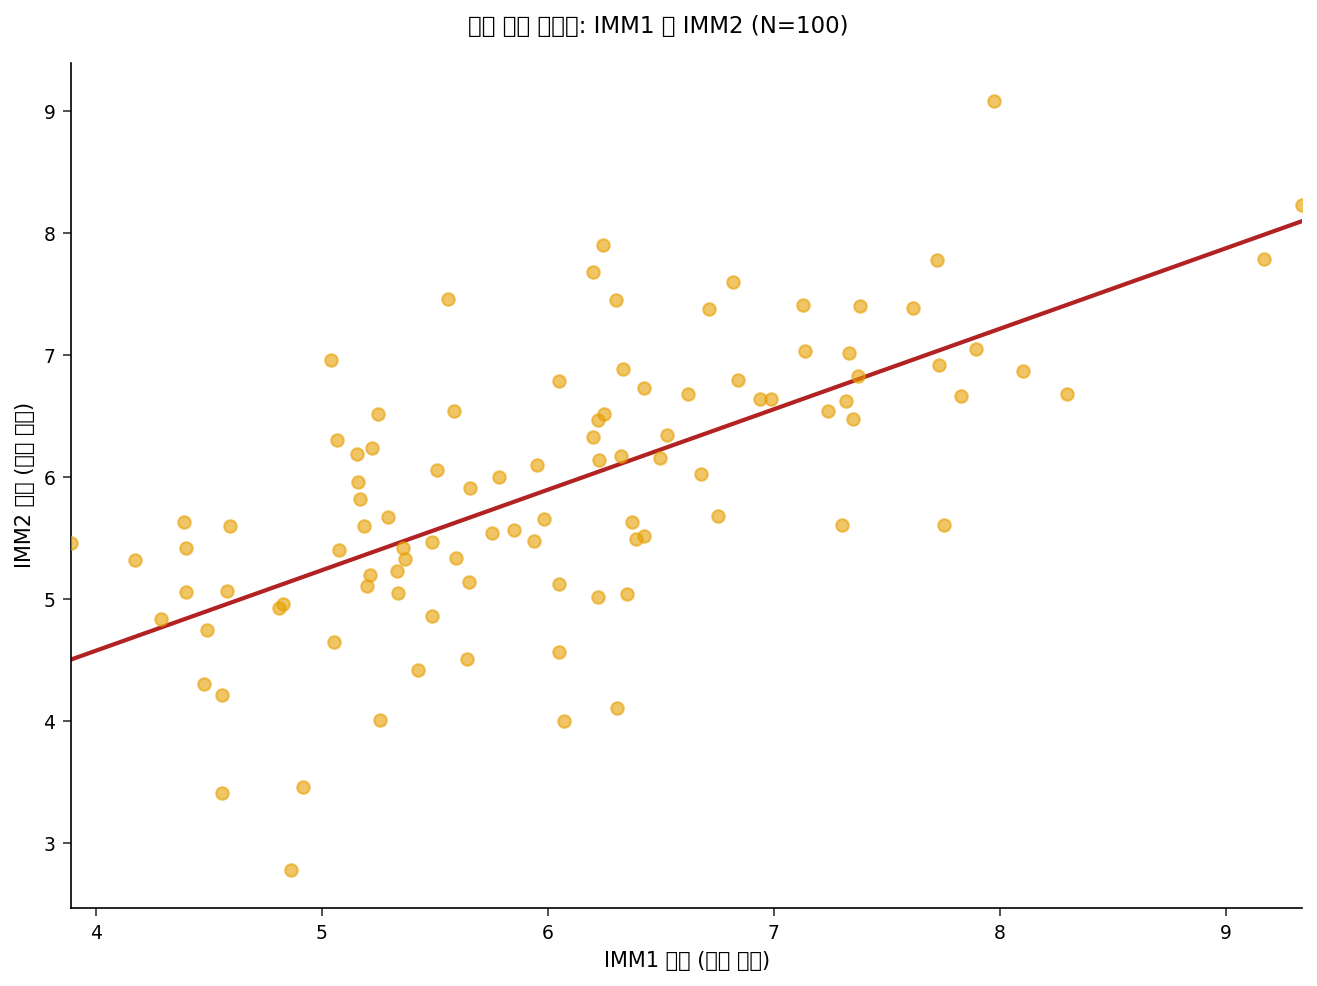

In [3]:
/* --------------------------------------------------------
   두 면역 모듈 유전자의 산점도: 모듈 내부 공발현이 실재하며
   대체로 단조적임을 확인하는 시각적 점검
   -------------------------------------------------------- */
처리 SGPLOT 데이터=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS 라벨='IMM1 발현 (면역 모듈)';
    YAXIS 라벨='IMM2 발현 (면역 모듈)';
    제목 '면역 모듈 공발현: IMM1 대 IMM2 (N=100)';
실행;
제목;

상승 추세는 두 면역 유전자가 함께 오르내린다는 것을 확인해 주며, 이는 아래 행렬에서 나타나는
그들의 양의 Spearman 상관에 대한 시각적 대응물이다.

---

In [4]:
/* --------------------------------------------------------
   9개 유전자 전체에 대한 Spearman 상관
   nosimple은 단순 통계 블록을 억제한다;
   outs=는 후속 네트워크 단계를 위해 Spearman 행렬을 기록한다
   -------------------------------------------------------- */
처리 CORR 데이터=work.expr spearman nosimple
    outs=work.gene_corr;
    변수 imm1-imm3 cyc1-cyc3 met1-met3;
    제목 'Spearman 상관 행렬: 9개 유전자 공발현 패널';
실행;
제목;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/b3750d2b-da6b-4c1a-b7cc-6495e2170665/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


행렬을 세 개의 대각 블록으로 읽어라. **면역** 블록(IMM1-IMM3)이 가장 긴밀하게 공발현되며
(rho 약 0.63~0.72), **세포주기** 블록(CYC1-CYC3)은 중간이고(약 0.29~0.41), **대사** 블록
(MET1-MET3)은 가장 약하다(약 0.13~0.25). 블록 밖 항목 — 서로 다른 모듈에 속한 유전자 쌍 — 은
0에 가깝다. 다음 셀은 모듈 내부 대 모듈 간 대비를 정량화하고, 그 뒤의 히트맵은 블록 구조를
눈에 보이게 만든다.

---

In [5]:
/* --------------------------------------------------------
   상관 행렬(유전자당 한 행)을 긴 형식(gene_x, gene_y, rho)으로
   재구성하고, 각 쌍을 모듈 내부/모듈 간으로 태그한다. 9개 유전자
   -> 81개 쌍 행이므로 100 관측치 상한으로 잃는 것이 없다.
   -------------------------------------------------------- */
데이터 work.corr_long;
    설정 work.gene_corr(조건=(_TYPE_='SCORR'));
    길이 gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    배열 g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    배열 gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    반복 k = 1 까지 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        출력;
    종료;
    유지 gene_x gene_y rho mod_x mod_y same_module;
실행;

/* --------------------------------------------------------
   모듈 내부 대 모듈 간 Spearman rho (비대각 항목만)
   -------------------------------------------------------- */
처리 평균 데이터=work.corr_long(조건=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    분류 same_module;
    변수 rho;
    라벨 rho='Spearman rho' same_module='동일 모듈 여부(1=예, 0=아니오)';
    제목 'Spearman rho: 모듈 내부(1) 대 모듈 간(0)';
실행;
제목;

                                            Spearman rho: 모듈 내부(1) 대 모듈 간(0)                                            

                                                  The MEANS Procedure

                                         Analysis Variable : rho Spearman rho

                                                               N
                 동일 모듈 여부(1=예, 0=아니오)                        Obs        Mean      Minimum      Maximum
                 -------------------------------------------------------------------------------------
                 0                                            54      -0.007       -0.185        0.162
                 1                                            18       0.402        0.127        0.718
                 -------------------------------------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


`same_module=1` 행은 모듈 내부 쌍을, `same_module=0` 행은 모듈 간 쌍을 집계한다. 모듈 내부
상관은 분명하게 양의 값으로 평균되는 반면 모듈 간 상관은 0에 가깝게 평균되어, 모듈들이 거의
독립적인 공발현 커뮤니티로 작동함을 확인해 준다.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


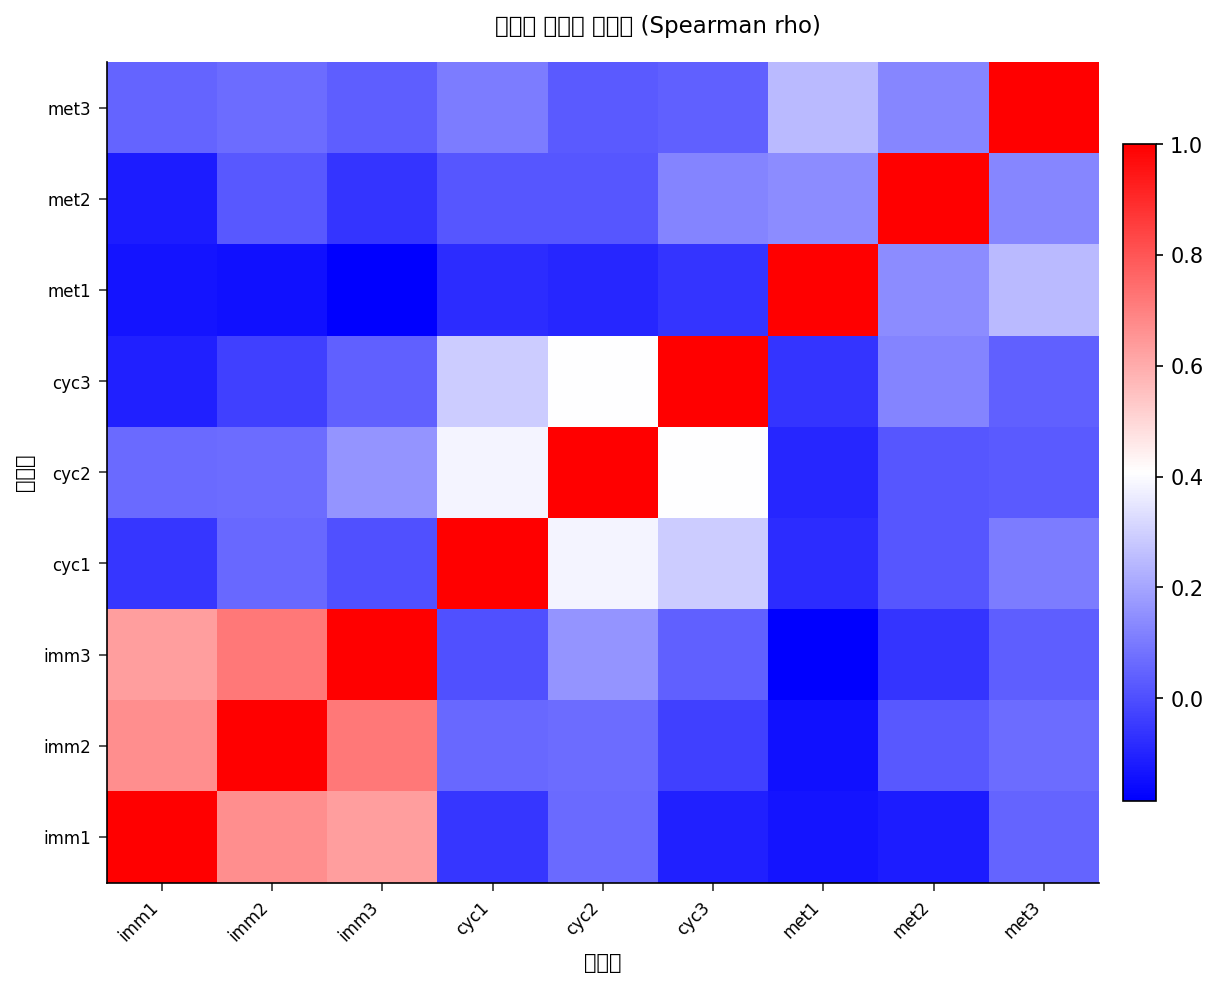

In [6]:
/* --------------------------------------------------------
   전체 9x9 Spearman 행렬의 히트맵. HEATMAPPARM는 각 유전자 쌍의
   사전 계산된 rho를 그린다; 파랑-흰색-빨강 스케일은 약한 쌍을
   흰색에 중심을 두고 강한 쌍을 포화시킨다.
   -------------------------------------------------------- */
처리 SGPLOT 데이터=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS 라벨='유전자' discreteorder=데이터;
    YAXIS 라벨='유전자' discreteorder=데이터;
    제목 '유전자 공발현 히트맵 (Spearman rho)';
실행;
제목;

세 개의 붉은 블록이 대각선을 따라 자리 잡는다 — 면역, 세포주기, 대사 모듈 — 반면 주변 셀은
거의 흰색이다. 면역 블록이 가장 진하며, 이는 위 행렬에서 가장 높은 모듈 내부 상관과 일치한다.

---

In [7]:
/* --------------------------------------------------------
   네트워크 엣지 목록: |rho|가 임계값을 넘는 각 비순서 유전자 쌍
   (gene_x < gene_y)을 유지한다. 이 엣지들이 Cytoscape 같은 도구로
   내보내기 위한 공발현 네트워크를 정의한다.
   -------------------------------------------------------- */
데이터 work.network_edges;
    설정 work.corr_long(조건=(gene_x < gene_y));
    만약 abs(rho) >= 0.24;
실행;

처리 인쇄 데이터=work.network_edges noobs label;
    변수 gene_x gene_y mod_x mod_y rho;
    라벨 gene_x='유전자 X' gene_y='유전자 Y' mod_x='모듈 X' mod_y='모듈 Y' rho='Spearman rho';
    제목 '공발현 네트워크 엣지 (|Spearman rho| >= 0.24)';
실행;
제목;

/* 외부 네트워크 시각화를 위해 엣지 목록을 내보낸다 */
처리 EXPORT 데이터=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
실행;

                                          공발현 네트워크 엣지 (|Spearman rho| >= 0.24)                                          

      유전자 X        유전자 Y      모듈 X      모듈 Y  Spearman rho
imm1         imm2         imm       imm       0.6708351085
imm1         imm3         imm       imm       0.6308427619
imm2         imm3         imm       imm       0.7179122524
cyc1         cyc2         cyc       cyc       0.3821865118
cyc1         cyc3         cyc       cyc        0.288211415
cyc2         cyc3         cyc       cyc       0.4054041891
met1         met3         met       met       0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### 해석

Spearman 분석은 설계된 3개 모듈 구조를 100개 표본으로부터 직접 복원했다. 아래 수치들은 PROC
CORR 행렬과 이 노트북에서 생성된 모듈 내부/모듈 간 요약에서 읽은 것이다:

- **면역 모듈(IMM1-IMM3)** 은 가장 긴밀하게 공발현되는 블록으로, 쌍별 rho가 약 0.63~0.72
  (평균 ~0.67)이며 IMM2와 IMM3 사이에 가장 강한 단일 엣지를 가진다.
- **세포주기 모듈(CYC1-CYC3)** 은 중간 정도로 공발현되며, 쌍별 rho가 약 0.29~0.41
  (평균 ~0.36)이다.
- **대사 모듈(MET1-MET3)** 은 가장 약한 블록으로, 쌍별 rho가 약 0.13~0.25(평균 ~0.17)이며 —
  생성기에서의 작은 신호 부하와 일치한다.
- **모듈 간 쌍** 은 평균적으로 거의 0이며(평균 rho ~-0.01, 평균 |rho| ~0.07, 최대 |rho| ~0.18),
  따라서 세 모듈은 거의 독립적인 커뮤니티로 작동한다.

|rho| >= 0.24 에서 임계값 처리를 하면 위에 출력된 네트워크 엣지 목록이 나온다. 살아남은 모든
엣지는 모듈 내부에 속한다: 세 개의 면역 쌍과 세 개의 세포주기 쌍이 모두 임계값을 넘고, 가장
강한 대사 쌍(MET1-MET3)이 여기에 합류한다. 어떤 모듈 간 쌍도 살아남지 못하므로, 공발현
네트워크는 세 개의 생물학적 모듈로 깔끔하게 분리된다. 엣지 목록은 Cytoscape와 같은 외부
네트워크 도구에서 시각화하기 위해 `gene_coexpression_edges.csv`로 내보내진다.

이 실습 예제는 공발현 분석을 위한 핵심 PROC CORR 워크플로를 보여준다: 발현 데이터에 적합한
순위 기반 계수를 선택하고, 상관 행렬에서 모듈 구조를 읽어내며, 모듈 내부 대 모듈 간 강도를
정량화하고, 네트워크 구축을 위해 행렬을 임계값 처리된 엣지 목록으로 축약한다.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 대외비
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>